<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/14_mediation-and-moderation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 14: Mediation

This homework assignment is designed to give you practice with mediation. You won't need to load in any data for this homework -- we'll simulate data instead.

---
## 1. Simulating data (3 points)


In this homework, we're going to simulate the relationship between age, word reading experience, and reading comprehension skill. Older children tend to be better at reading comprehension tasks, but this isn't just an inherent part of getting older. It's a combination of gaining more experience with reading, oral language skills, and executive functions development. In this homework, though, we're going to simplify this relationship down to a direct effect of age on reading comprehension (since improvements in oral language skills and executive functions are more guaranteed as children age than reading practice is), and a mediation of word reading experience.

In graphical form:
![picture](https://drive.google.com/uc?id=1wdm9xuiJhBJor99-9GnicO2_rzkGWtfN)

Writing the relationship out formally:

$$x = \beta_{xa} a + \beta_{x0} + \epsilon_{x}$$

$$c = \beta_{ca} a + \beta_{cx} x + \beta_{c0} + \epsilon_c$$



$c$ is reading comprehension, $x$ is word reading experience, and $a$ is age. $\beta_{c0}$ and $\beta_{x0}$ are intercept terms for their respective formulas, and $\epsilon_{c}$ and $\epsilon_{x}$ are gaussian noise terms. We'll start by writing a function, `simulate_data`, that can simulate this relationship. The input values are set and the function structure is provided below. Complete the function such that it takes in those input variables and generates $age$, $x$, and $c$ values. Use `runif()` to generate ages. Use `rnorm()` to generate the noise terms.

In [1]:
sample_size = 100 # How many children in data set?
age_lo = 80     # minimum age, in months
age_hi = 200    # maximum age, in months
beta_xa = 0.5   # amount by which experience changes for increase of one month in age
beta_x0 = -5    # amount of experience when age = 0 (not interpretable, since minimum age for this data is 80 months)
sd_x = 50       # standard dev of gaussian noise term, epsilon_x
beta_ca = 0.8   # amount that comprehension score improves for every increase of one unit in age
beta_cx = 3     # amount that comprehension score improves for every increase of one unit in reading experience
beta_c0 = 10    # comprehension score when reading experience is 0.
sd_c = 85      # standard dev of gaussian noise term, epsilon_c

simulate_data <- function(sample_size, age_lo, age_hi, beta_xa,
                          beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c) {
  age <- runif(sample_size, age_lo, age_hi)
  epsilon_x <- rnorm(sample_size, mean = 0, sd = sd_x)
  epsilon_c <- rnorm(sample_size, mean = 0, sd = sd_c)
  
  x <- beta_xa * age + beta_x0 + epsilon_x
  c <- beta_ca * age + beta_cx * x + beta_c0 + epsilon_c
  
  return(data.frame(age = age, x = x, c = c))
}

dat <- simulate_data(sample_size, age_lo, age_hi, beta_xa, beta_x0, sd_x, beta_ca, beta_cx, beta_c0, sd_c)
head(dat)

,age,x,c
,<dbl>,<dbl>,<dbl>
1,189.2089,7.907681,188.6830
2,101.4199,76.985915,410.4491
3,147.8613,77.449400,214.8437
4,197.1106,34.601198,203.1095
5,191.6558,81.321510,486.8549
6,190.3913,157.551680,528.0297


---
## 2. Visualizing Data (2 point)

Load the `tidyverse` library.

In [3]:
library(tidyverse)

a) Plot the relationship between age and reading comprehension.

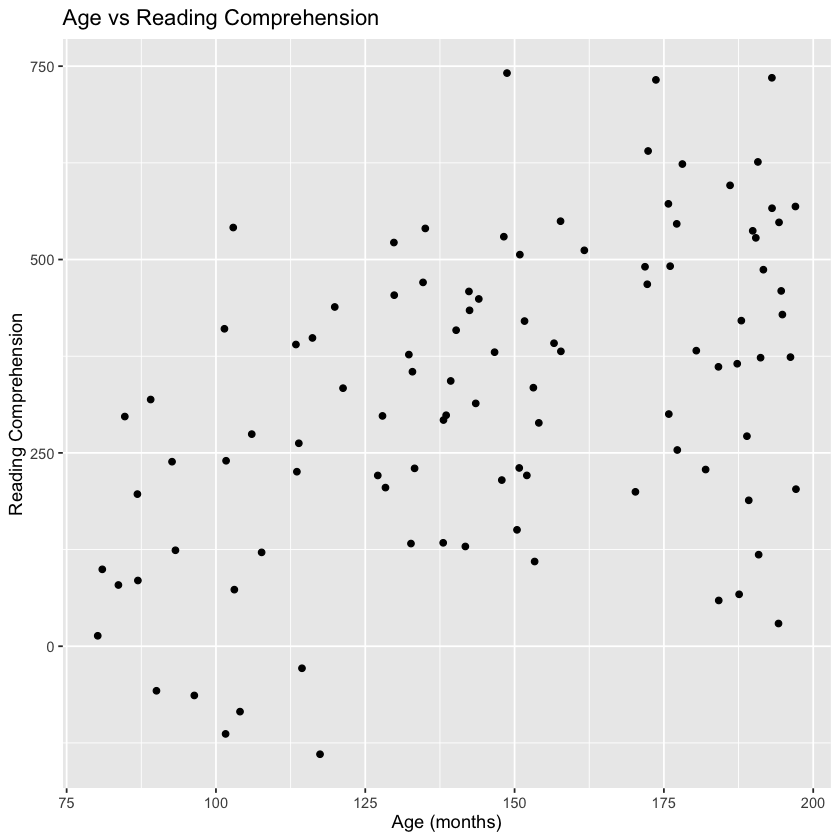

In [4]:
ggplot(dat, aes(x = age, y = c)) +
  geom_point() +
  labs(x = "Age (months)", y = "Reading Comprehension", 
       title = "Age vs Reading Comprehension")

b) Plot the relationship between reading experience, age, and reading comprehension.

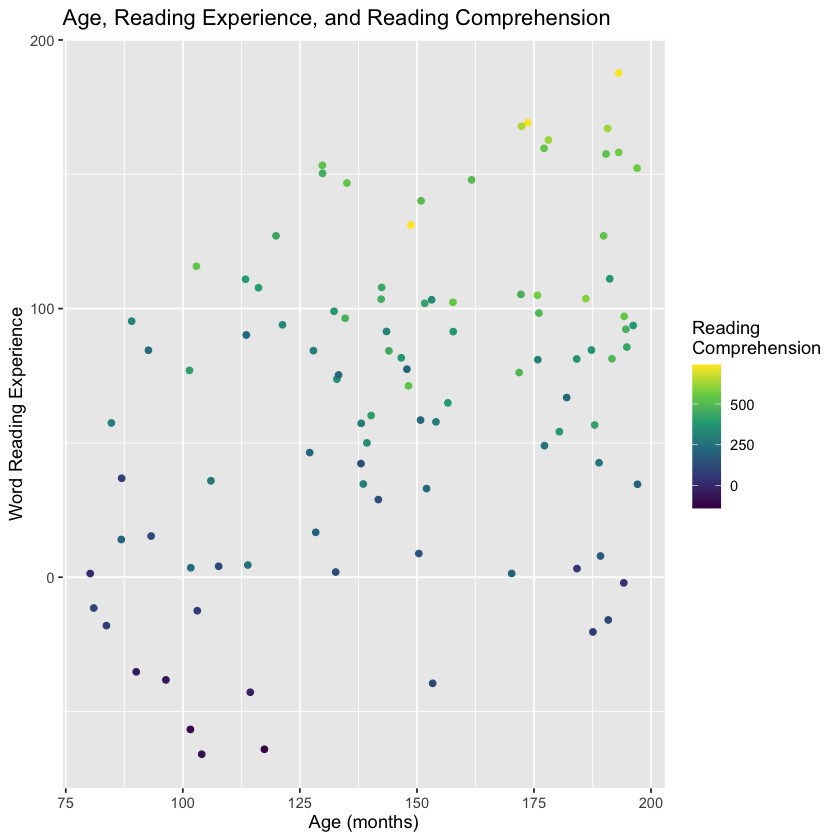

In [5]:
ggplot(dat, aes(x = age, y = x, color = c)) +
  geom_point() +
  scale_color_viridis_c() +
  labs(x = "Age (months)", y = "Word Reading Experience", 
       color = "Reading\nComprehension",
       title = "Age, Reading Experience, and Reading Comprehension")

---
## 3. Mediation Analysis (4 points)

Load the `mediation` library.

In [7]:
install.packages("mediation")
library(mediation)

also installing the dependencies ‘checkmate’, ‘htmlwidgets’, ‘zoo’, ‘gridExtra’, ‘htmlTable’, ‘colorspace’, ‘Formula’, ‘mvtnorm’, ‘sandwich’, ‘lpSolve’, ‘Hmisc’





The downloaded binary packages are in
	/var/folders/98/fcbf3bz156j770hhtccd780w0000gq/T//RtmpBxbq6p/downloaded_packages


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: mvtnorm

Loading required package: sandwich

mediation: Causal Mediation Analysis
Version: 4.5.1




Use the `mediate` function to determine whether `x` mediates the relationship between `age` and `c`. Use `summary()` to print the model results. *Hint: see the mediation and moderation tutorial.*

In [8]:
fitM <- lm(x ~ age, data = dat)
fitY <- lm(c ~ x + age, data = dat)
summary(fitM)
summary(fitY)

fitMed <- mediate(fitM, fitY, treat = "age", mediator = "x")
summary(fitMed)


Call:
lm(formula = x ~ age, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-115.367  -36.182   -3.344   40.538   97.397 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -31.8585    23.6716  -1.346    0.181    
age           0.6763     0.1567   4.315 3.82e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 54.63 on 98 degrees of freedom
Multiple R-squared:  0.1596,	Adjusted R-squared:  0.1511 
F-statistic: 18.62 on 1 and 98 DF,  p-value: 3.821e-05



Call:
lm(formula = c ~ x + age, data = dat)

Residuals:
     Min       1Q   Median       3Q      Max 
-141.373  -50.558   -7.967   50.354  231.207 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  26.7253    33.6828   0.793  0.42946    
x             2.8807     0.1424  20.226  < 2e-16 ***
age           0.7092     0.2411   2.942  0.00408 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 77.03 on 97 degrees of freedom
Multiple R-squared:  0.8509,	Adjusted R-squared:  0.8478 
F-statistic: 276.8 on 2 and 97 DF,  p-value: < 2.2e-16



Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

               Estimate 95% CI Lower 95% CI Upper   p-value    
ACME            1.95218      1.09265      2.84335 < 2.2e-16 ***
ADE             0.71706      0.22418      1.15623 < 2.2e-16 ***
Total Effect    2.66923      1.71508      3.58580 < 2.2e-16 ***
Prop. Mediated  0.73090      0.55375      0.89962 < 2.2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Sample Size Used: 100 


Simulations: 1000 


---
## 5. Reflection (1 point)
How do you interpret these results? Why do you think the analysis yielded this result?

> From the output, we can see that both results are significant. The ADE of age on reading comprehension is around 0.72, and it is statistically significant (p<0.001). This means that even after accounting for word reading experience, age still has a significant direct effect on comprehension. The ACME through word reading experience is around 1.95, also significant (p<0.001), which means that a substantial portion of age's effect on comprehension operates through word reading experiences, meaning that as children gets older, they gain more reading experience, which in turn correlates positively with their comprehension. Also, about 73% of the total effect of age on reading comprehension is mediated through word reading experience. From here, we can see that word reading experience significantly mediates the relationship between age and reading comprehension. While age still does have a modest direct effect on comprehension, the majority of agee's influence operates indirectly. 

**DUE:** 5pm EST, March 26, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*